# Mumbai Survival Index
## A Data-Driven Analysis of Cost of Living for Students & Freshers

### Problem Statement
Mumbai is one of the most expensive cities in India. Students and freshers often struggle with high rent, travel, and daily expenses. This project analyzes cost of living data to understand whether a fresher can survive in Mumbai and what salary is required for a decent lifestyle.

## Objective
- Analyze housing prices in Mumbai
- Study salary vs expense ratio
- Identify affordable vs expensive areas
- Build a "Survival Score" for freshers
- Provide data-driven recommendations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving job_market_india.csv to job_market_india.csv
Saving livingcost_india_all_inr.csv to livingcost_india_all_inr.csv
Saving Mumbai.csv to Mumbai.csv


In [4]:
mumbai_df = pd.read_csv("Mumbai.csv")
jobs_df = pd.read_csv("job_market_india.csv")
living_df = pd.read_csv("livingcost_india_all_inr.csv")

In [5]:
mumbai_df.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,4850000,720,Kharghar,1,1,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1,4500000,600,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
2,6700000,650,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
3,4500000,650,Kharghar,1,1,1,0,0,1,0,...,1,1,1,0,0,0,0,0,1,0
4,5000000,665,Kharghar,1,1,1,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0


In [6]:
jobs_df.head()

,Job Title,Location,Salary,Monthly Salary,Locality,State
0,Robotics / STEM Trainer,"Indore, Madhya Pradesh","₹1,80,000 - ₹3,60,000 a year",270000.0,NaN,Madhya Pradesh
1,HTML Developers - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,NaN,Banaswadi,Karnataka
2,Java Developers - Freshers,"Banaswadi, Bengaluru, Karnataka",Not specified,NaN,Banaswadi,Karnataka
3,"Teachers - Pre-Primary and Primary (English, M...","Pulivendla, Andhra Pradesh","₹20,000 - ₹30,000 a month",25000.0,NaN,Andhra Pradesh
4,College Student,Remote,"₹15,000 - ₹20,000 a month",17500.0,Remote,Remote


In [7]:
living_df.head()

,city,cost_one_person_usd,rent_one_person_usd,monthly_salary_after_tax_usd,income_after_rent_usd,months_covered,cost_one_person_inr,rent_one_person_inr,monthly_salary_after_tax_inr,income_after_rent_inr,usd_to_inr_rate_used,source_url
0,Cost of Living in Andhra Pradesh,347.0,122.0,379.0,257.0,1.1,30488.74,10719.38,33300.38,22581.00,87.8638,https://livingcost.org/cost/india/ap
1,Cost of Living in Vijayawada,333.0,106.0,550.0,444.0,1.6,29258.65,9313.56,48325.09,39011.53,87.8638,https://livingcost.org/cost/india/ap/vijayawada
2,Cost of Living in Visakhapatnam,310.0,111.0,222.0,111.0,0.6,27237.78,9752.88,19505.76,9752.88,87.8638,https://livingcost.org/cost/india/ap/visakhapa...
3,Cost of Living in Assam,349.0,112.0,362.0,250.0,1.0,30664.47,9840.75,31806.70,21965.95,87.8638,https://livingcost.org/cost/india/as
4,Cost of Living in Guwahati,348.0,110.0,354.0,244.0,1.0,30576.60,9665.02,31103.79,21438.77,87.8638,https://livingcost.org/cost/india/as/guwahati


In [8]:
print(mumbai_df.shape)
print(jobs_df.shape)
print(living_df.shape)

(7719, 40)
(835, 6)
(103, 12)


In [9]:
print(mumbai_df.columns)
print(jobs_df.columns)
print(living_df.columns)

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator'],
      dtype='object')
Index(['Job Title', 'Location', 'Salary', 'Monthly Salary', 'Locality',
       'State'],
      dtype='object')
Index(['city', 'cost_one_person_usd', 'rent_one_person_usd',
       'monthly_salary_after_tax_usd', 'income_after_rent_usd',
       'months_covered', 'cost_one_person_inr', 'rent_one_person_inr',
       'monthly_salary_after_tax_inr', 'incom

In [10]:
mumbai_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7719 entries, 0 to 7718
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                7719 non-null   int64 
 1   Area                 7719 non-null   int64 
 2   Location             7719 non-null   object
 3   No. of Bedrooms      7719 non-null   int64 
 4   Resale               7719 non-null   int64 
 5   MaintenanceStaff     7719 non-null   int64 
 6   Gymnasium            7719 non-null   int64 
 7   SwimmingPool         7719 non-null   int64 
 8   LandscapedGardens    7719 non-null   int64 
 9   JoggingTrack         7719 non-null   int64 
 10  RainWaterHarvesting  7719 non-null   int64 
 11  IndoorGames          7719 non-null   int64 
 12  ShoppingMall         7719 non-null   int64 
 13  Intercom             7719 non-null   int64 
 14  SportsFacility       7719 non-null   int64 
 15  ATM                  7719 non-null   int64 
 16  ClubHo

In [11]:
jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Job Title       835 non-null    object 
 1   Location        835 non-null    object 
 2   Salary          835 non-null    object 
 3   Monthly Salary  497 non-null    float64
 4   Locality        254 non-null    object 
 5   State           835 non-null    object 
dtypes: float64(1), object(5)
memory usage: 39.3+ KB


In [12]:
living_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   city                          103 non-null    object 
 1   cost_one_person_usd           103 non-null    float64
 2   rent_one_person_usd           103 non-null    float64
 3   monthly_salary_after_tax_usd  103 non-null    float64
 4   income_after_rent_usd         103 non-null    float64
 5   months_covered                103 non-null    float64
 6   cost_one_person_inr           103 non-null    float64
 7   rent_one_person_inr           103 non-null    float64
 8   monthly_salary_after_tax_inr  103 non-null    float64
 9   income_after_rent_inr         103 non-null    float64
 10  usd_to_inr_rate_used          103 non-null    float64
 11  source_url                    103 non-null    object 
dtypes: float64(10), object(2)
memory usage: 9.8+ KB


## Initial Observation

Three datasets were successfully loaded into Google Colab for analysis:
1. Mumbai housing dataset
2. Indian job market dataset
3. Living cost dataset

The datasets contain information related to housing prices, fresher salaries, and living expenses, which will be used to build the Mumbai Survival Index.

In [13]:
mumbai_df.isnull().sum()

,0
Price,0
Area,0
Location,0
No. of Bedrooms,0
Resale,0
MaintenanceStaff,0
Gymnasium,0
SwimmingPool,0
LandscapedGardens,0
JoggingTrack,0


In [14]:
jobs_df.isnull().sum()

,0
Job Title,0
Location,0
Salary,0
Monthly Salary,338
Locality,581
State,0


In [15]:
living_df.isnull().sum()

,0
city,0
cost_one_person_usd,0
rent_one_person_usd,0
monthly_salary_after_tax_usd,0
income_after_rent_usd,0
months_covered,0
cost_one_person_inr,0
rent_one_person_inr,0
monthly_salary_after_tax_inr,0
income_after_rent_inr,0


## Data Cleaning Observation

The datasets contain some missing values and inconsistent formatting. Data cleaning is required before performing analysis to ensure accurate insights.

In [16]:
jobs_df["Monthly Salary"].head(20)

,Monthly Salary
0,270000.0
1,NaN
2,NaN
3,25000.0
4,17500.0
5,NaN
6,NaN
7,NaN
8,18683.5
9,NaN


In [17]:
jobs_df = jobs_df.dropna(subset=["Monthly Salary"])

In [18]:
jobs_df["Monthly Salary"].isnull().sum()

np.int64(0)

In [19]:
jobs_df.shape

(497, 6)

## Data Cleaning Summary

The datasets were inspected for missing values and formatting issues.

- The Mumbai housing dataset contained no missing values.
- The job market dataset had missing salary values, which were removed.
- The living cost dataset contained no missing values.

After cleaning, the datasets were ready for analysis and visualization.

In [20]:
mumbai_df["Price"].describe()

,Price
count,7.719000e+03
mean,1.506165e+07
std,2.052100e+07
min,2.000000e+06
25%,5.300000e+06
50%,9.500000e+06
75%,1.700000e+07
max,4.200000e+08


## Housing Price Statistics Analysis

The Mumbai housing dataset contains 7,719 property records. The average property price is significantly high, while the median price is much lower, indicating strong inequality in housing prices.

The presence of extremely expensive luxury properties increases the overall average price, making affordability difficult for students and freshers.

In [21]:
top_expensive = mumbai_df.groupby(
    "Location"
)["Price"].mean().sort_values(
    ascending=False
).head(10)
top_expensive

,Price
Location,
MG Road,4.200000e+08
Agripada,2.600000e+08
juhu tara,1.800000e+08
Hanuman Nagar,1.550000e+08
worli sea face,1.500000e+08
Haji Ali,1.400000e+08
Morya Nagar,1.368000e+08
Lower Parel,1.300817e+08
Mahalaxmi,1.135000e+08


## Most Expensive Locations Analysis

The analysis shows that locations such as MG Road, Agripada, Juhu Tara, and Worli Sea Face have extremely high average property prices.

These premium areas are likely dominated by luxury housing and are financially inaccessible for most students and freshers. The data also highlights significant housing inequality across Mumbai locations.

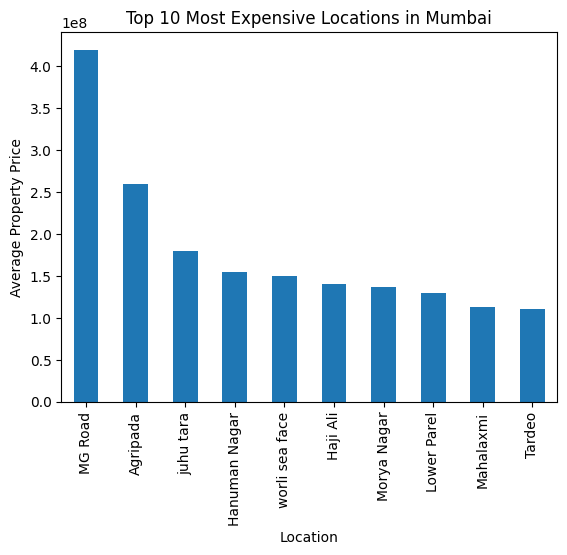

In [22]:
top_expensive.plot(kind="bar")
plt.title("Top 10 Most Expensive Locations in Mumbai")
plt.xlabel("Location")
plt.ylabel("Average Property Price")
plt.show()

## Chart Observation

The visualization shows that a few premium locations dominate Mumbai’s housing market with extremely high property prices. MG Road appears as a major outlier, indicating the presence of ultra-luxury real estate.

This highlights the affordability gap between premium and average residential areas in Mumbai.

In [23]:
cheap_locations = mumbai_df.groupby(
    "Location"
)["Price"].mean().sort_values(
    ascending=True
).head(10)
cheap_locations

,Price
Location,
Vasind,2000000.0
Asangaon,2035000.0
ulhasnagar 4,2050000.0
Sector-26 Taloja,2100000.0
Gundavali Gaothan,2164000.0
Sector16 Ulwe,2300000.0
Syndicate,2300000.0
Karjat,2348400.0
Chedda Nagar,2400000.0


## Affordable Locations Analysis

Locations such as Vasind, Asangaon, Karjat, and Ambarnath have comparatively lower average property prices.

These suburban and peripheral regions appear significantly more affordable for students and freshers compared to premium areas in central Mumbai.

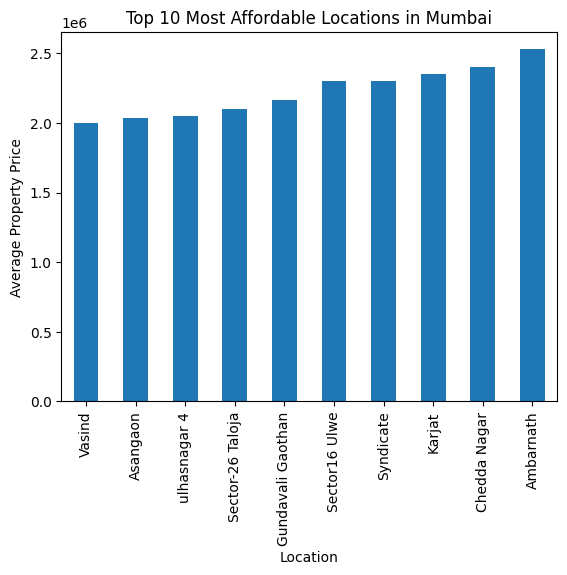

In [24]:
cheap_locations.plot(kind="bar")
plt.title("Top 10 Most Affordable Locations in Mumbai")
plt.xlabel("Location")
plt.ylabel("Average Property Price")
plt.show()

## Affordable Housing Insight

The chart highlights several comparatively affordable locations in Mumbai such as Vasind, Asangaon, Karjat, and Ambarnath.

These areas have significantly lower average property prices compared to premium regions, making them more suitable for students, middle-income families, and freshers entering the workforce.

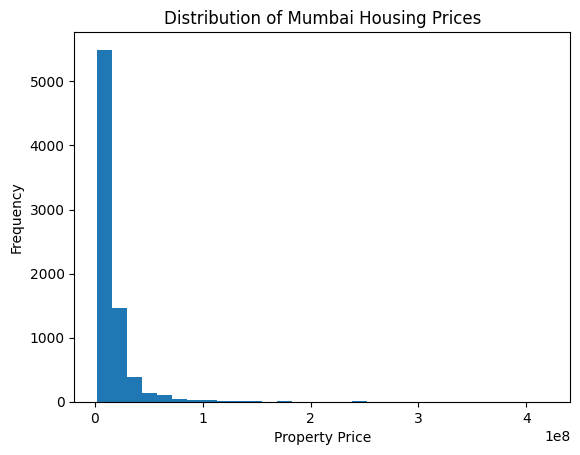

In [25]:
mumbai_df["Price"].plot(kind="hist", bins=30)
plt.title("Distribution of Mumbai Housing Prices")
plt.xlabel("Property Price")
plt.ylabel("Frequency")
plt.show()

## Housing Price Distribution Insight

The histogram shows that Mumbai housing prices are highly right-skewed. Most properties fall within lower and middle price ranges, while a small number of ultra-luxury properties have extremely high prices.

This indicates significant inequality in Mumbai’s real estate market and highlights affordability challenges for students and freshers.

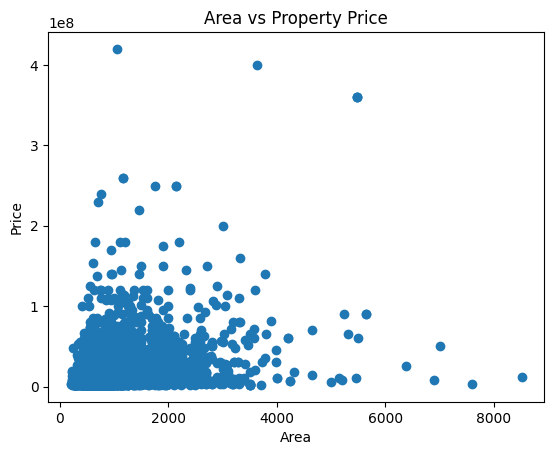

In [26]:
plt.scatter(
    mumbai_df["Area"],
    mumbai_df["Price"]
)
plt.title("Area vs Property Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

## Area vs Price Insight

The scatter plot shows a general positive relationship between property area and price, indicating that larger properties tend to be more expensive.

However, the relationship is not perfectly linear. Some smaller properties have very high prices, suggesting that factors such as location, luxury amenities, and premium neighborhoods also play a major role in determining housing prices in Mumbai.

In [27]:
jobs_df["Monthly Salary"].describe()

,Monthly Salary
count,497.000000
mean,63087.595050
std,126922.462764
min,180.000000
25%,14000.000000
50%,19250.000000
75%,28000.000000
max,939847.175000


## Salary Statistics Insight

The salary analysis reveals significant income inequality within the dataset. While the average salary appears relatively high, the median monthly salary is only around ₹19,250, indicating that most students and freshers earn modest incomes.

A few extremely high salary values increase the overall average salary, making the median a more reliable indicator of typical fresher earnings.

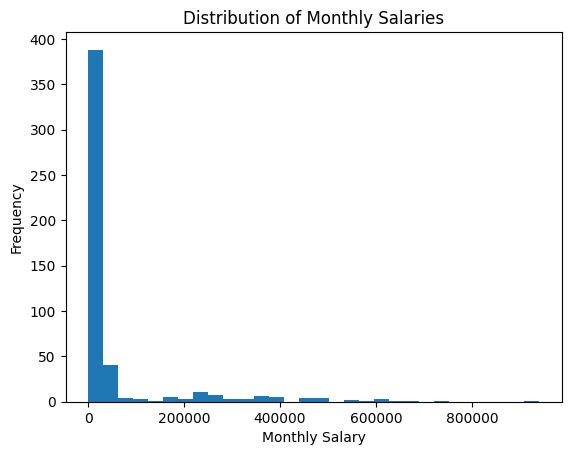

In [28]:
jobs_df["Monthly Salary"].plot(
    kind="hist",
    bins=30
)
plt.title("Distribution of Monthly Salaries")
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.show()

## Salary Distribution Insight

The salary distribution is highly right-skewed, indicating that most students and freshers earn salaries in lower income ranges, while only a small number of individuals receive extremely high salaries.

The presence of high-income outliers compresses the visualization and highlights significant income inequality within the job market.

In [30]:
jobs_df["Salary Category"] = pd.cut(
    jobs_df["Monthly Salary"],
    bins=[0, 20000, 50000, 1000000],
    labels=["Low Income", "Medium Income", "High Income"]
)

In [31]:
jobs_df["Salary Category"].value_counts()

,count
Salary Category,
Low Income,281
Medium Income,145
High Income,71


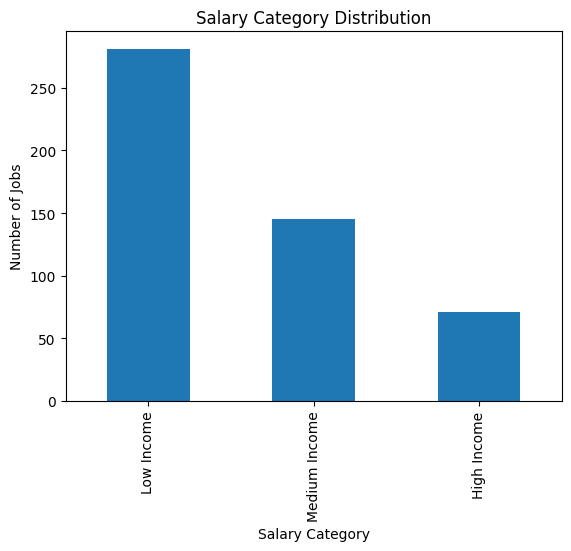

In [32]:
jobs_df["Salary Category"].value_counts().plot(
    kind="bar"
)
plt.title("Salary Category Distribution")
plt.xlabel("Salary Category")
plt.ylabel("Number of Jobs")
plt.show()

## Salary Category Insight

The majority of jobs in the dataset fall under the low-income category, while relatively few jobs belong to the high-income range.

This suggests that many students and freshers may face affordability challenges when living in expensive metropolitan cities such as Mumbai.

In [33]:
living_df["cost_one_person_inr"].describe()

,cost_one_person_inr
count,103.000000
mean,34218.258058
std,6449.380767
min,23196.040000
25%,29302.580000
50%,33651.840000
75%,37254.250000
max,61943.980000


## Living Cost Analysis Insight

The average monthly living cost for one person is significantly high when compared to typical fresher salaries identified in the job market dataset.

The analysis suggests that many students and freshers may face financial pressure when trying to manage housing, transportation, and daily expenses in expensive urban environments.

In [34]:
top_cities = living_df.sort_values(
    "cost_one_person_inr",
    ascending=False
).head(10)

top_cities[[
    "city",
    "cost_one_person_inr"
]]

,city,cost_one_person_inr
39,Cost of Living in Mumbai,61943.98
83,Cost of Living in Madurai,56760.01
36,Cost of Living in Maharashtra,48061.50
43,Cost of Living in Pune,45425.58
42,Cost of Living in Navi Mumbai,44195.49
10,Cost of Living in Gujarat,43141.13
17,Cost of Living in Delhi,42965.40
44,Cost of Living in Thane,42789.67
16,Cost of Living in Haryana,41823.17
78,"Cost of Living in Hyderabad, Telangana",41295.99


## Expensive Cities Insight

Mumbai has the highest monthly living cost in the dataset at around ₹61,944 for one person. Nearby cities such as Pune, Navi Mumbai, and Thane also show high living costs, but Mumbai remains the most expensive.

This strengthens the project’s main argument that surviving independently in Mumbai can be difficult for students and freshers with entry-level salaries.

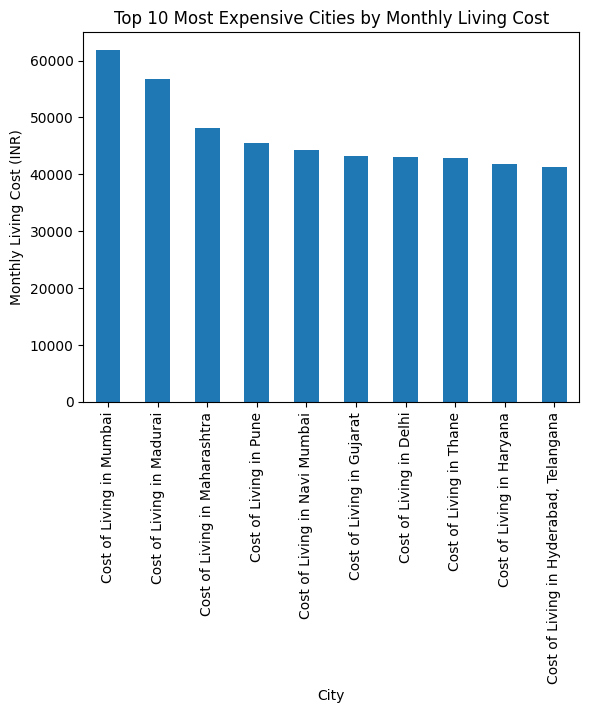

In [35]:
top_cities.plot(
    x="city",
    y="cost_one_person_inr",
    kind="bar",
    legend=False
)

plt.title("Top 10 Most Expensive Cities by Monthly Living Cost")
plt.xlabel("City")
plt.ylabel("Monthly Living Cost (INR)")
plt.show()

In [36]:
jobs_df["Monthly Salary"].median()

19250.0

In [40]:
median_salary = jobs_df["Monthly Salary"].median()
average_living_cost = living_df["cost_one_person_inr"].mean()
remaining_income = median_salary - average_living_cost
# Survival Classification
if remaining_income < 0:
    survival_status = "Critical"
elif remaining_income < 10000:
    survival_status = "Difficult"
elif remaining_income < 25000:
    survival_status = "Manageable"
else:
    survival_status = "Comfortable"

# Final Output
print("Median Salary:", median_salary)
print("Average Living Cost:", average_living_cost)
print("Remaining Income:", remaining_income)
print("Survival Status:", survival_status)

Median Salary: 19250.0
Average Living Cost: 34218.25805825243
Remaining Income: -14968.258058252432
Survival Status: Critical


## Survival Index Insight

The analysis shows that the median fresher salary is significantly lower than the average monthly living cost.

The calculated remaining income is negative, resulting in a **Critical** survival status. This suggests that many students and freshers may face financial difficulty sustaining an independent lifestyle in Mumbai without shared accommodation, financial support, or additional income sources.

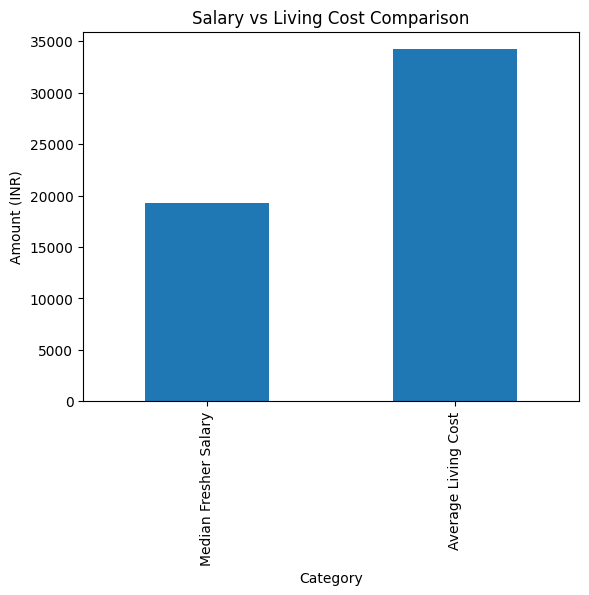

In [38]:
comparison = pd.DataFrame({
    "Category": ["Median Fresher Salary", "Average Living Cost"],
    "Amount": [median_salary, average_living_cost]
})

comparison.plot(
    x="Category",
    y="Amount",
    kind="bar",
    legend=False
)

plt.title("Salary vs Living Cost Comparison")

plt.ylabel("Amount (INR)")

plt.show()

## Salary vs Living Cost Insight

The comparison clearly shows that the median fresher salary is substantially lower than the average monthly living cost.

This suggests that many students and freshers may find it financially difficult to sustain an independent lifestyle in expensive urban cities like Mumbai without shared accommodation, financial assistance, or additional income sources.

# Recommendations

Based on the analysis, the following recommendations can help students and freshers manage living expenses in expensive urban cities like Mumbai:

### 1. Shared Accommodation
Students and freshers should consider shared housing options to reduce rental burden and monthly expenses.

### 2. Preference for Affordable Areas
Suburban regions such as Vasind, Karjat, and Ambarnath appear significantly more affordable compared to premium locations in central Mumbai.

### 3. Budget Planning
Proper monthly budgeting for rent, transportation, food, and utilities is essential for financial sustainability.

### 4. Remote or Hybrid Work Opportunities
Remote work can reduce relocation and transportation costs, improving overall affordability.

### 5. Skill Development for Higher Income
Upskilling and acquiring in-demand professional skills may help freshers access better-paying job opportunities and improve financial stability.

# Conclusion

This project analyzed housing prices, fresher salaries, and living costs to evaluate the affordability of living in Mumbai for students and freshers.

The analysis revealed significant housing and income inequality across locations and salary ranges. While premium areas in Mumbai have extremely high housing costs, most fresher salaries remain concentrated in lower income categories.

The Survival Index analysis showed that the median fresher salary is lower than the average monthly living cost, indicating that independent living in expensive urban cities like Mumbai can be financially challenging for many students and freshers.

Overall, the project highlights the importance of affordable housing, financial planning, skill development, and shared accommodation strategies for improving urban financial sustainability.